# Customer Segmentation with K-Means and PCA

The goal is to group mall customers into segments based on their income and spending behavior without any labels.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## 1. Load and Explore the Data

In [33]:
df = pd.read_csv('data/Mall_Customers.csv')
print(df.shape)
df.head()

(200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [34]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [35]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## 2. Select Features and Scale

I'm using Annual Income and Spending Score because they directly describe who has money, and who actually spends it.

K-Means uses distance to group points. If one feature has a much larger range than another, it will dominate the calculation. StandardScaler fixes this by putting all features on the same scale.

In [36]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before scaling — Income mean:', X[:, 0].mean().round(1), '| Spending mean:', X[:, 1].mean().round(1))
print('After scaling  — Income mean:', X_scaled[:, 0].mean().round(2), '| Spending mean:', X_scaled[:, 1].mean().round(2))

Before scaling — Income mean: 60.6 | Spending mean: 50.2
After scaling  — Income mean: -0.0 | Spending mean: -0.0


## 3. Find the Right Number of Clusters (Elbow Method)

K-Means requires K upfront. I'll try K from 2 to 10 and plot the inertia (WCSS) each time. The point where the curve stops dropping sharply is the best K (elbow).

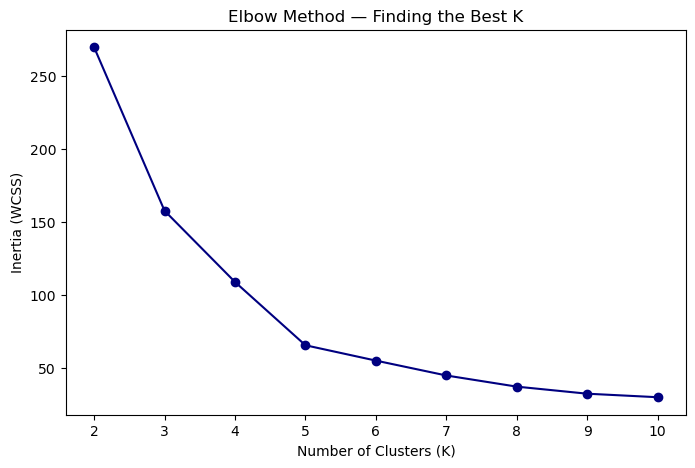

In [37]:
inertia = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o', color='navy')
plt.title('Elbow Method — Finding the Best K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(range(2, 11))
plt.show()

## 4. Confirm with Silhouette Score

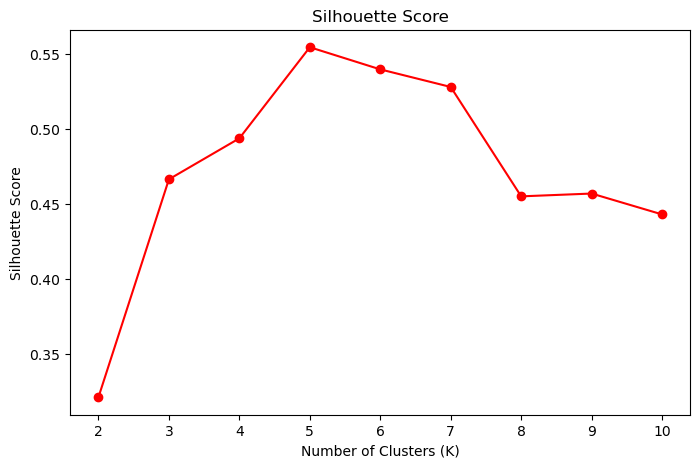

In [38]:
sil_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores, marker='o', color='red')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.show()

## 5. Train the Final Model with K=5

In [39]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print('Cluster sizes:')
print(df['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


## 6. Visualize the Clusters

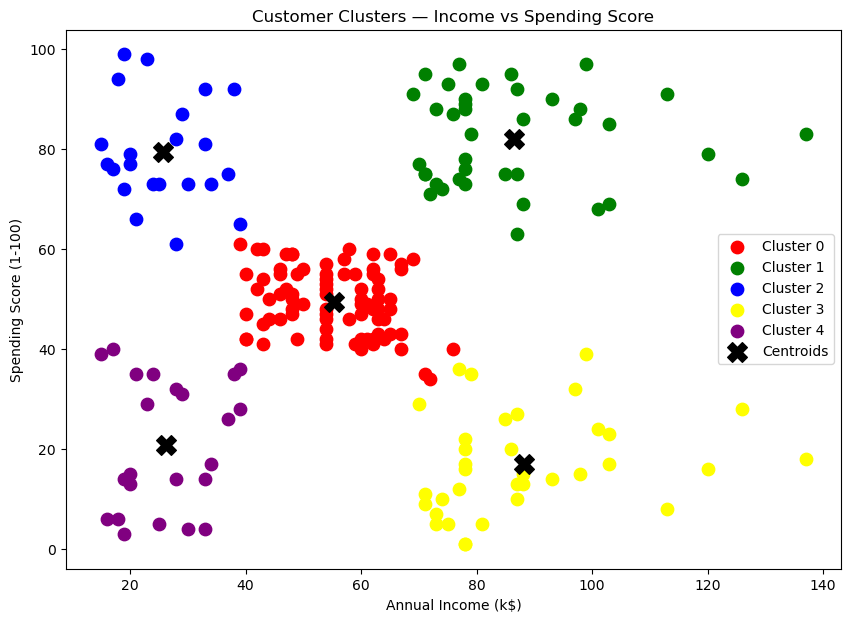

In [40]:
colors = ['red', 'green', 'blue', 'yellow', 'purple']

plt.figure(figsize=(10, 7))

for i in range(5):
    mask = df['Cluster'] == i
    plt.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        color=colors[i],
        label=f'Cluster {i}',
        s=80
    )

# Show centroids on the original scale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], color='black', marker='X', s=200, label='Centroids')

plt.title('Customer Clusters — Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## 7. Read the Cluster Profiles

Now I calculate the mean values per cluster to understand what each group actually looks like.

In [41]:
profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
profile['Count'] = df['Cluster'].value_counts().sort_index()
profile

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


Based on the mean values above, I can label each cluster:

| Cluster | Income | Spending | Label |
|---------|--------|----------|-------|
| 0 | High | Low | Frugal Elite — have money but don't spend it |
| 1 | Low | Low | Budget Conscious — low income, low spending |
| 2 | Medium | Medium | Averages — balanced profile |
| 3 | High | High | VIPs — best customers, retain them |
| 4 | Low | High | High-Potential Youth — spend despite low income |

## 8. PCA: Reduce 3 Features to 2D

Now I add Age as a third feature and use PCA to compress all three into 2 components so I can visualize them. PCA finds the directions of maximum variance in the data and projects onto those.

The tradeoff: the axes are no longer 'income' or 'age' but instead they become mathematical combinations of all three features.

In [42]:
X_full = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_full_scaled)

print('Variance captured by PC1:', round(pca.explained_variance_ratio_[0] * 100, 1), '%')
print('Variance captured by PC2:', round(pca.explained_variance_ratio_[1] * 100, 1), '%')
print('Total variance retained: ', round(pca.explained_variance_ratio_.sum() * 100, 1), '%')

Variance captured by PC1: 44.3 %
Variance captured by PC2: 33.3 %
Total variance retained:  77.6 %


## 9. Run K-Means on PCA Components and Visualize

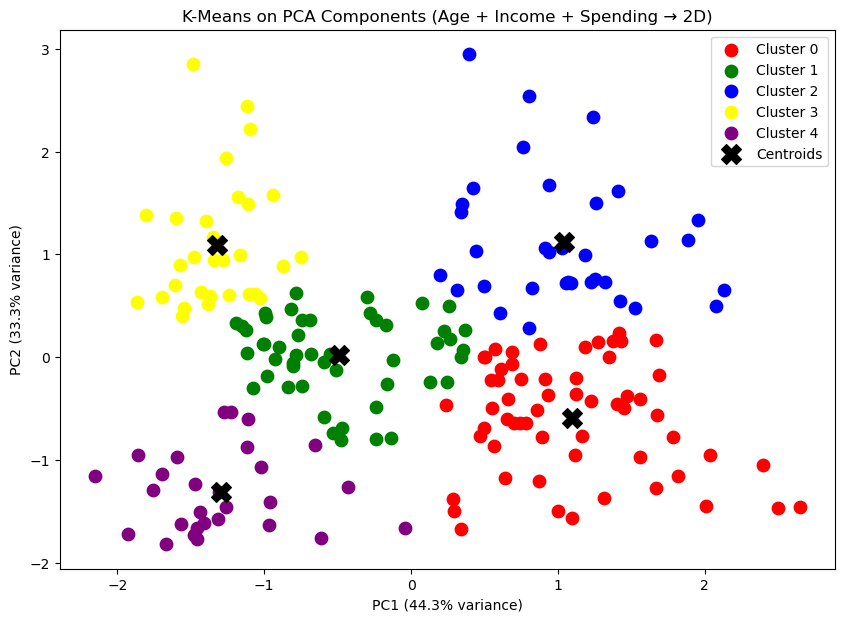

In [43]:
kmeans_pca = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_PCA'] = kmeans_pca.fit_predict(X_pca)

plt.figure(figsize=(10, 7))

for i in range(5):
    mask = df['Cluster_PCA'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], color=colors[i], label=f'Cluster {i}', s=80)

plt.scatter(kmeans_pca.cluster_centers_[:, 0], kmeans_pca.cluster_centers_[:, 1],
            color='black', marker='X', s=200, label='Centroids')

plt.title('K-Means on PCA Components (Age + Income + Spending → 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.show()